In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from tensorflow.keras.datasets import mnist

2026-02-03 14:47:37.408987: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-03 14:47:37.432854: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 14:47:37.968786: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
(Xtr, Ltr), (X_test, L_test)=mnist.load_data()
Xtr[0,:,:]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [5]:
def normalization(X):
    # flat the images
    X_temp = X.reshape(X.shape[0], X.shape[1]*X.shape[2])
    # Rescale pixels values from range [0,255] to [0,1]
    X_temp = X_temp.astype('float32')/255.0 # the 255.0 trigger the auto conversion from uint8 to float to avoid value overflow in later operations
    # Per-pixel mean normalization: normalize value of each pixel across all images
    X_norm = X_temp - X_temp.mean(axis=0) #The mean of the X_norm should be close to zero
    return X_norm

#preprocess all the images in the train set.
X_trainset = normalization(Xtr)
X_testset = normalization(X_test)
print("Shape of X_train", X_trainset.shape)
print("Shape of X_test", X_testset.shape)

Shape of X_train (60000, 784)
Shape of X_test (10000, 784)


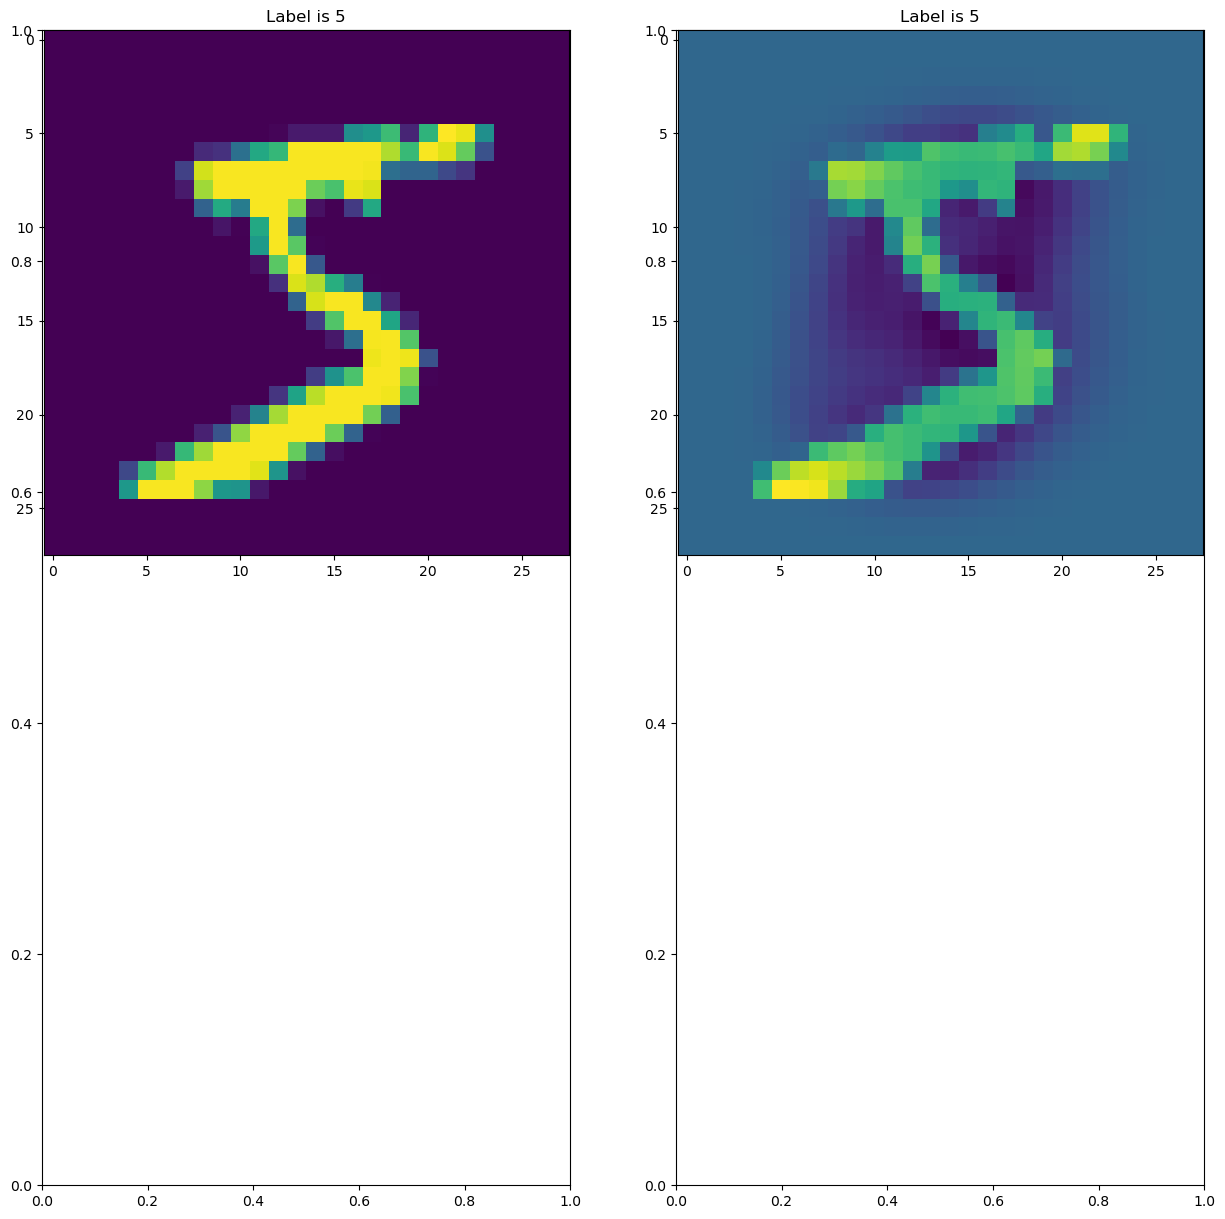

In [6]:
#Visualize before-after preprocesing.

fig, ax=plt.subplots(nrows=1, ncols=2, figsize=(15,15))
ax0=plt.subplot(2,2,1)
ax1=plt.subplot(2,2,2)

Image=Xtr[0,:,:]
Label=Ltr[0]
Image1=X_trainset[0,:].reshape(28,28)
Label1=Ltr[0]


ax0.set_title('Label is {Label}'.format(Label=Label))
ax0.imshow(Image)
ax1.set_title('Label is {Label}'.format(Label=Label1))
ax1.imshow(Image1)


plt.show()
plt.close()

In [57]:
#Traing phase
num_sample=5000 #the training samples should be high enough to improve the coverage for the classes
Tr_set=X_trainset[:num_sample,:]
Ltr_set=Ltr[:num_sample]
Tr_set.shape

(5000, 784)

In [58]:
def predict(X):
    num_test=X.shape[0]
    Lpred=np.zeros(num_test, dtype=Ltr_set.dtype)
    
    for i in range(num_test):
        # Distance calculated by L1: Manhattan distance
        distances=np.sum(np.abs(Tr_set-X[i,:]),axis=1) #axis 1 is the column which contains the pixel values
        # Distance calculated by L2: Euclidean distance
        # distances = np.sqrt(np.sum(np.square(Tr_set - X[i, :]), axis=1))
        # distances = np.sum(np.square(Tr_set - X[i, :]), axis=1) # skip the square root operation as we just take the min index anyway
        
        min_index= np.argmin(distances)
        Lpred[i]=Ltr_set[min_index]
    return Lpred

In [ ]:
from collections import Counter

# predict with k nearest neighbor
def predict_kNN(X, k=3):
    num_test = X.shape[0]
    Lpred = np.zeros(num_test, dtype=Ltr_set.dtype)
    
    for i in range(num_test):
        # 1. Calculate distances (using L2 as you found it better)
        distances = np.sum(np.square(Tr_set - X[i, :]), axis=1) # skip the square root operation as we just take the min index anyway
        
        # 2. Find indices of the k smallest distances
        # argsort returns indices that would sort the array
        closest_indices = np.argsort(distances)[:k]
        
        # 3. Get the labels for these k closest images
        closest_labels = Ltr_set[closest_indices]
        
        # 4. Voting: Find the most common label
        # Counter(closest_labels).most_common(1) returns [(label, count)]
        vote = Counter(closest_labels).most_common(1)[0][0]
        Lpred[i] = vote
        
    return Lpred

In [60]:
# Take a small test set for quick result
Test_images = X_testset[:500,:]
Test_lable = L_test[:500]

# Labels_predicted=predict(Test_images)
Labels_predicted=predict_kNN(Test_images)

print("Accuracy:", np.mean(Labels_predicted==Test_lable))



Accuracy: 0.918
